# **DISEASES & BIOFUNCTIONS**

In [1]:
import pandas as pd

# === 1️⃣ INPUT FILE ===
# Replace with your uploaded file name or path
file_path = "/content/S_Diseases_&_Biofunctions.xlsx"   # or .xlsx

# === 2️⃣ INPUT GENE LIST ===
genes_of_interest = [
    "CREB1","ADM","APOLD1","ARG1","ATF3","AURKA","BHLHE40","BIRC5","CCN1",
    "CCNA2","CCNB1","CCNB2","CD3D","CHRM3","CXCL8","DUSP1","EGR1","ESRRG",
    "FASN","FLT1","FOS","FOSB","GADD45B","GAL","GDA","GLDC","HSD11B1","IL6",
    "INA","JUN","LCN2","LPL","MKI67","MMP1","NFIL3","NR4A1","NR4A2","PCK1",
    "PER1","PPARG","PPARGC1A","PPP1R15A","PTGS2","RBP4","SIK1","SLC2A3",
    "SMPD3","SOCS2","SOD2","STC1","TF","VEGFA","ZFP36","CDK1","MMP9","CYP1A1"
]

# === 3️⃣ LOAD FILE ===
if file_path.endswith(".xlsx"):
    df = pd.read_excel(file_path)
else:
    df = pd.read_csv(file_path)

# Clean up column names (strip whitespace)
df.columns = df.columns.str.strip()

# === 4️⃣ PROCESS EACH ROW ===
def find_common_genes(molecule_str):
    if pd.isna(molecule_str):
        return []
    # Split molecule list by commas and remove spaces
    mols = [m.strip().upper() for m in molecule_str.split(",")]
    # Compare with genes of interest
    common = sorted(set(mols) & set(g.upper() for g in genes_of_interest))
    return common

# Apply to each row
df["Common Genes"] = df["Molecules"].apply(find_common_genes)
df["# Common Genes"] = df["Common Genes"].apply(len)

# Convert gene list to comma-separated string
df["Common Genes"] = df["Common Genes"].apply(lambda x: ", ".join(x) if x else "-")

# === 5️⃣ SAVE & DISPLAY ===
out_path = "/content/IPA_Diseases_Functions_with_CommonGenes.xlsx"
df.to_excel(out_path, index=False)

# Display top results
print("Common gene mapping complete. File saved to:", out_path)
display(df.head(10))


✅ Common gene mapping complete. File saved to: /content/IPA_Diseases_Functions_with_CommonGenes.xlsx


,Diseases or Functions Annotation (Directly relevant),References,p-value,Predicted Activation State,Activation z-score,# Molecules,Molecules,Common Genes,# Common Genes
0,Inflammatory response,"Ye, Jianzhou, et al. “NB-UVB Irradiation Atten...",9.830000e-40,Increased,3.854,122,"ACKR1,ACP5,ADIPOQ,ADM,AGTR1,AOC3,APOBEC3A,ARG1...","ADM, ARG1, ATF3, CXCL8, DUSP1, EGR1, FASN, FLT...",24
1,Chemotaxis of leukocytes,"Gao, Changyong, and Jianhong Li. “Exploring th...",2.230000e-10,Increased,3.757,37,"CCL13,CCL18,CCL22,CCL27,CCR7,CD47,CXCL1,CXCL10...","CXCL8, DUSP1, FLT1, IL6, LCN2, MMP9, PPARG, VEGFA",8
2,Cell movement of granulocytes,"Zangrilli, Arianna, et al. “Improvement of Pso...",2.050000e-20,Increased,3.735,58,"ACKR1,ADIPOQ,ADM,ADRB2,AIM2,AOC3,CCL13,CCR7,CD...","ADM, CXCL8, DUSP1, FOS, IL6, LCN2, MMP9, NR4A1...",11
3,T cell migration,"Lee, Dahae, et al. “The Anti-Inflammatory Effe...",2.430000e-17,Increased,3.701,47,"ACKR1,ADIPOQ,AIM2,AOC3,APOD,BACH2,CCL18,CCL22,...","CXCL8, IL6, MMP9, NR4A1, PTGS2",5
4,Migration of mononuclear leukocytes,"Turchin, Irina, and Marc Bourcier. “The Role o...",1.450000e-21,Increased,3.696,62,"ACKR1,ADIPOQ,AIM2,AOC3,APOD,BACH2,CCL18,CCL22,...","CXCL8, FLT1, FOS, IL6, JUN, MMP9, NFIL3, NR4A1...",11
5,Cell movement of T lymphocytes,"Chen, Yiqiao, et al. “Exploring Mast Cell-CD8 ...",5.920000e-17,Increased,3.663,44,"ACKR1,ADIPOQ,AIM2,AOC3,APOD,BACH2,CCL18,CCL22,...","CXCL8, IL6, MMP9, NR4A1, PTGS2",5
6,Lymphocyte migration,"Zhao, Liang, et al. “GRP78 Downregulation in K...",1.340000e-19,Increased,3.652,57,"ACKR1,ADIPOQ,AIM2,AOC3,APOD,BACH2,CCL18,CCL22,...","CXCL8, FOS, IL6, JUN, MMP9, NFIL3, NR4A1, PTGS2",8
7,Cell movement of mononuclear leukocytes,"Turchin, Irina, and Marc Bourcier. “The Role o...",1.660000e-26,Increased,3.650,77,"ACKR1,ADIPOQ,ADRB2,AIM2,AOC3,APOD,BACH2,CCL13,...","CCN1, CXCL8, DUSP1, FLT1, FOS, IL6, JUN, MMP9,...",13
8,Migration of lymphatic system cells,"Ter-Ovanesyan, Irina, et al. “An Update on the...",1.490000e-20,Increased,3.507,59,"ACKR1,ADIPOQ,ADRB2,AIM2,AOC3,APOD,BACH2,CCL18,...","CXCL8, FOS, IL6, JUN, MMP9, NFIL3, NR4A1, PTGS...",9
9,Cell movement of myeloid cells,"Moreau, Joshua M., et al. “T-Cell Adhesion in ...",6.500000e-25,Increased,3.479,82,"ACKR1,ADIPOQ,ADM,ADRB2,AIM2,AOC3,ARG1,BAG4,BCL...","ADM, ARG1, CCN1, CXCL8, DUSP1, FLT1, FOS, IL6,...",17


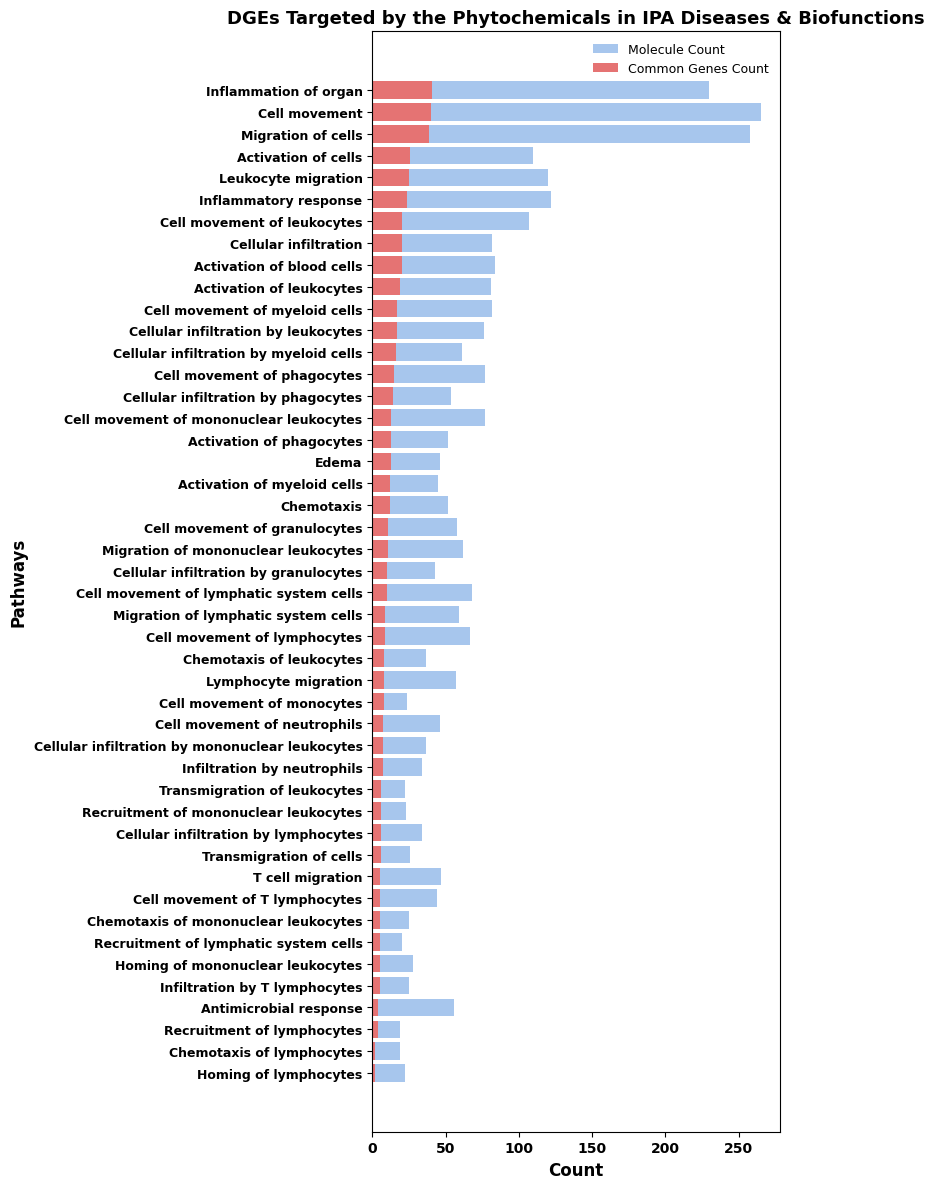

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Input data
# ===============================
data = [
    ("Inflammation of organ", 230, 41),
    ("Cell movement", 265, 40),
    ("Migration of cells", 258, 39),
    ("Activation of cells", 110, 26),
    ("Leukocyte migration", 120, 25),
    ("Inflammatory response", 122, 24),
    ("Cell movement of leukocytes", 107, 20),
    ("Cellular infiltration", 82, 20),
    ("Activation of blood cells", 84, 20),
    ("Activation of leukocytes", 81, 19),
    ("Cell movement of myeloid cells", 82, 17),
    ("Cellular infiltration by leukocytes", 76, 17),
    ("Cellular infiltration by myeloid cells", 61, 16),
    ("Cell movement of phagocytes", 77, 15),
    ("Cellular infiltration by phagocytes", 54, 14),
    ("Cell movement of mononuclear leukocytes", 77, 13),
    ("Activation of phagocytes", 52, 13),
    ("Edema", 46, 13),
    ("Activation of myeloid cells", 45, 12),
    ("Chemotaxis", 52, 12),
    ("Cell movement of granulocytes", 58, 11),
    ("Migration of mononuclear leukocytes", 62, 11),
    ("Cellular infiltration by granulocytes", 43, 10),
    ("Cell movement of lymphatic system cells", 68, 10),
    ("Migration of lymphatic system cells", 59, 9),
    ("Cell movement of lymphocytes", 67, 9),
    ("Chemotaxis of leukocytes", 37, 8),
    ("Lymphocyte migration", 57, 8),
    ("Cell movement of monocytes", 24, 8),
    ("Cell movement of neutrophils", 46, 7),
    ("Cellular infiltration by mononuclear leukocytes", 37, 7),
    ("Infiltration by neutrophils", 34, 7),
    ("Transmigration of leukocytes", 22, 6),
    ("Recruitment of mononuclear leukocytes", 23, 6),
    ("Cellular infiltration by lymphocytes", 34, 6),
    ("Transmigration of cells", 26, 6),
    ("T cell migration", 47, 5),
    ("Cell movement of T lymphocytes", 44, 5),
    ("Chemotaxis of mononuclear leukocytes", 25, 5),
    ("Recruitment of lymphatic system cells", 20, 5),
    ("Homing of mononuclear leukocytes", 28, 5),
    ("Infiltration by T lymphocytes", 25, 5),
    ("Antimicrobial response", 56, 4),
    ("Recruitment of lymphocytes", 19, 4),
    ("Chemotaxis of lymphocytes", 19, 2),
    ("Homing of lymphocytes", 22, 2),
]

# ===============================
# Data setup and sorting
# ===============================
df = pd.DataFrame(data, columns=["Pathways", "Molecule Count", "Common Genes Count"])

# Sort by Common Genes (descending) so highest appears at the top
df = df.sort_values(by="Common Genes Count", ascending=False).reset_index(drop=True)

# ===============================
# Plot overlapping bars
# ===============================
plt.figure(figsize=(8, 12))

y = range(len(df))

# Full bars for total molecules (background)
plt.barh(y, df["Molecule Count"], color="#a7c6ed", label="Molecule Count")

# Overlapping bars for common genes (foreground)
plt.barh(y, df["Common Genes Count"], color="#e57373", label="Common Genes Count")

# Axis labels and title
plt.xlabel("Count", fontsize=12, fontweight='bold')
plt.ylabel("Pathways", fontsize=12, fontweight='bold')
plt.title("DGEs Targeted by the Phytochemicals in IPA Diseases & Biofunctions",
          fontsize=13, fontweight='bold')

# Bold tick labels
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(y, df["Pathways"], fontsize=9, fontweight='bold')

# Legend (top right)
plt.legend(loc="upper right", frameon=False, fontsize=9)

# Reverse y-axis so highest is at top
plt.gca().invert_yaxis()

plt.tight_layout()

# Save & show
plt.savefig("/content/dges_overlap_barplot_sorted_by_common_genes.png", dpi=300, bbox_inches="tight")
plt.show()

# **IPA Canonical Pathways**

In [10]:
import pandas as pd

# === 1️⃣ INPUT FILE ===
# Replace with your uploaded file name or path
file_path = "/content/CP.xlsx"   # or .xlsx

# === 2️⃣ INPUT GENE LIST ===
genes_of_interest = [
    "CREB1","ADM","APOLD1","ARG1","ATF3","AURKA","BHLHE40","BIRC5","CCN1",
    "CCNA2","CCNB1","CCNB2","CD3D","CHRM3","CXCL8","DUSP1","EGR1","ESRRG",
    "FASN","FLT1","FOS","FOSB","GADD45B","GAL","GDA","GLDC","HSD11B1","IL6",
    "INA","JUN","LCN2","LPL","MKI67","MMP1","NFIL3","NR4A1","NR4A2","PCK1",
    "PER1","PPARG","PPARGC1A","PPP1R15A","PTGS2","RBP4","SIK1","SLC2A3",
    "SMPD3","SOCS2","SOD2","STC1","TF","VEGFA","ZFP36","CDK1","MMP9","CYP1A1"
]

# === 3️⃣ LOAD FILE ===
if file_path.endswith(".xlsx"):
    df = pd.read_excel(file_path)
else:
    df = pd.read_csv(file_path)

# Clean up column names (strip whitespace)
df.columns = df.columns.str.strip()

# === 4️⃣ PROCESS EACH ROW ===
def find_common_genes(molecule_str):
    if pd.isna(molecule_str):
        return []
    # Split molecule list by commas and remove spaces
    mols = [m.strip().upper() for m in molecule_str.split(",")]
    # Compare with genes of interest
    common = sorted(set(mols) & set(g.upper() for g in genes_of_interest))
    return common

# Apply to each row
df["Common Genes"] = df["Molecules"].apply(find_common_genes)
df["# Common Genes"] = df["Common Genes"].apply(len)

# Convert gene list to comma-separated string
df["Common Genes"] = df["Common Genes"].apply(lambda x: ", ".join(x) if x else "-")

# === 5️⃣ SAVE & DISPLAY ===
out_path = "/content/IPA_CP_with_CommonGenes.xlsx"
df.to_excel(out_path, index=False)

# Display top results
print("Common gene mapping complete. File saved to:", out_path)
display(df.head(10))


✅ Common gene mapping complete. File saved to: /content/IPA_CP_with_CommonGenes.xlsx


,Ingenuity Canonical Pathways,-log(p-value),Ratio,z-score,Molecules,Common Genes,# Common Genes
0,Antimicrobial peptides,9.66,0.245,3.464,"KLK6,LCN2,LTF,LYZ,PGLYRP4,PI3,PRSS3,RNASE7,S10...",LCN2,1
1,Interferon alpha/beta signaling,11.60,0.211,2.500,"EGR1,IFI27,IFI6,IFIT1,IFIT3,IRF6,ISG15,MX1,OAS...",EGR1,1
2,Interferon gamma signaling,6.11,0.122,2.309,"GBP1,GBP5,GBP6,HLA-DPA1,IRF6,OAS1,OAS2,OAS3,OA...",-,0
3,Keratinization,12.30,0.120,2.200,"DSC2,DSG2,IVL,KLK13,KLK8,KRT15,KRT16,KRT18,KRT...",-,0
4,OAS antiviral response,4.70,0.444,2.000,"OAS1,OAS2,OAS3,OASL",-,0
5,Role of IL-17A in Psoriasis,6.73,0.429,2.000,"CXCL1,CXCL8,DEFB4A,S100A7,S100A8,S100A9",CXCL8,1


# **IPA ML DISEASE PATHWAYS**

In [2]:
import pandas as pd

# === 1️⃣ INPUT FILE ===
# Replace with your uploaded file name or path
file_path = "/content/ML Pathways.xlsx"   # or .xlsx

# === 2️⃣ INPUT GENE LIST ===
genes_of_interest = [
    "CREB1","ADM","APOLD1","ARG1","ATF3","AURKA","BHLHE40","BIRC5","CCN1",
    "CCNA2","CCNB1","CCNB2","CD3D","CHRM3","CXCL8","DUSP1","EGR1","ESRRG",
    "FASN","FLT1","FOS","FOSB","GADD45B","GAL","GDA","GLDC","HSD11B1","IL6",
    "INA","JUN","LCN2","LPL","MKI67","MMP1","NFIL3","NR4A1","NR4A2","PCK1",
    "PER1","PPARG","PPARGC1A","PPP1R15A","PTGS2","RBP4","SIK1","SLC2A3",
    "SMPD3","SOCS2","SOD2","STC1","TF","VEGFA","ZFP36","CDK1","MMP9","CYP1A1"
]

# === 3️⃣ LOAD FILE ===
if file_path.endswith(".xlsx"):
    df = pd.read_excel(file_path)
else:
    df = pd.read_csv(file_path)

# Clean up column names (strip whitespace)
df.columns = df.columns.str.strip()

# === 4️⃣ PROCESS EACH ROW ===
def find_common_genes(molecule_str):
    if pd.isna(molecule_str):
        return []
    # Split molecule list by commas and remove spaces
    mols = [m.strip().upper() for m in molecule_str.split(",")]
    # Compare with genes of interest
    common = sorted(set(mols) & set(g.upper() for g in genes_of_interest))
    return common

# Apply to each row
df["Common Genes"] = df["Molecules"].apply(find_common_genes)
df["# Common Genes"] = df["Common Genes"].apply(len)

# Convert gene list to comma-separated string
df["Common Genes"] = df["Common Genes"].apply(lambda x: ", ".join(x) if x else "-")

# === 5️⃣ SAVE & DISPLAY ===
out_path = "/content/IPA_ML_with_CommonGenes.xlsx"
df.to_excel(out_path, index=False)

# Display top results
print("Common gene mapping complete. File saved to:", out_path)
display(df.head(10))


✅ Common gene mapping complete. File saved to: /content/IPA_Diseases_Functions_with_CommonGenes.xlsx


,My Pathways,References,-log(p-value),Ratio,Molecules,Molecules Count,Common Genes,# Common Genes
0,Allergic inflammation,"Man, Alessandra-Mădălina, et al. “Inflammation...",3.70,0.143,"ADRB2,BCL6,CHRM3,GATA3,GZMA,IL6",6,"CHRM3, IL6",2
1,Oxidative stress,"Blagov, Alexander, et al. “The Role of Oxidati...",4.23,0.176,"BBS2,DDIT3,PPARG,PPARGC1A,SELL,SOD2",6,"PPARG, PPARGC1A, SOD2",3
2,Ichthyosis,"Lilly, Evelyn, and Christopher G. Bunick. “Con...",2.45,0.129,"ALOX12B,CYP4F22,KRT9,TGM1",4,-,0
3,Neuroinflammation,"Lada, Georgia, et al. “Brain Structure and Con...",3.59,0.136,"CMPK2,GBP5,IL6,PTGS2,PYCARD,STAT1",6,"IL6, PTGS2",2
4,Psoriasis,"Nair, Pragya A., and Talel Badri. “Psoriasis.”...",2.05,0.100,"CXCL1,CXCL8,IL36A,IL36RN",4,CXCL8,1
5,Familial insulin resistance,"Gyldenløve, Mette, et al. “Patients with Psori...",4.41,0.152,"ACACB,FASN,INSR,PCK1,PLIN2,PPARG,PPARGC1A",7,"FASN, PCK1, PPARG, PPARGC1A",4
6,Insulin resistance,"Parraga, Shirley P., and Steven R. Feldman. “I...",6.24,0.184,"ADIPOQ,ADRB2,AGTR1,CARHSP1,CIDEC,FKBP5,IGFBP6,...",9,PPARG,1
7,Hyperglycemia,"Yongpisarn, Tanat, et al. “Hyperglycemia Is a ...",2.58,0.106,"ADIPOQ,CARHSP1,INSR,PCK1,PPARG",5,"PCK1, PPARG",2
8,Metabolic syndrome X,"Takahashi, Hidetoshi, and Hajime Iizuka. “Psor...",3.23,0.118,"ADRB2,AGTR1,IL37,KIF2C,KLF9,PPARG",6,PPARG,1
9,Diabetic nephropathy,"Ishibashi, Masafumi, and Rie Shiiyama. “A Case...",2.45,0.129,"AGTR1,INSR,NR3C2,WIF1",4,-,0


✅ Saved: IPA_CanonicalPathways_Compact_RightAlign_300dpi.png


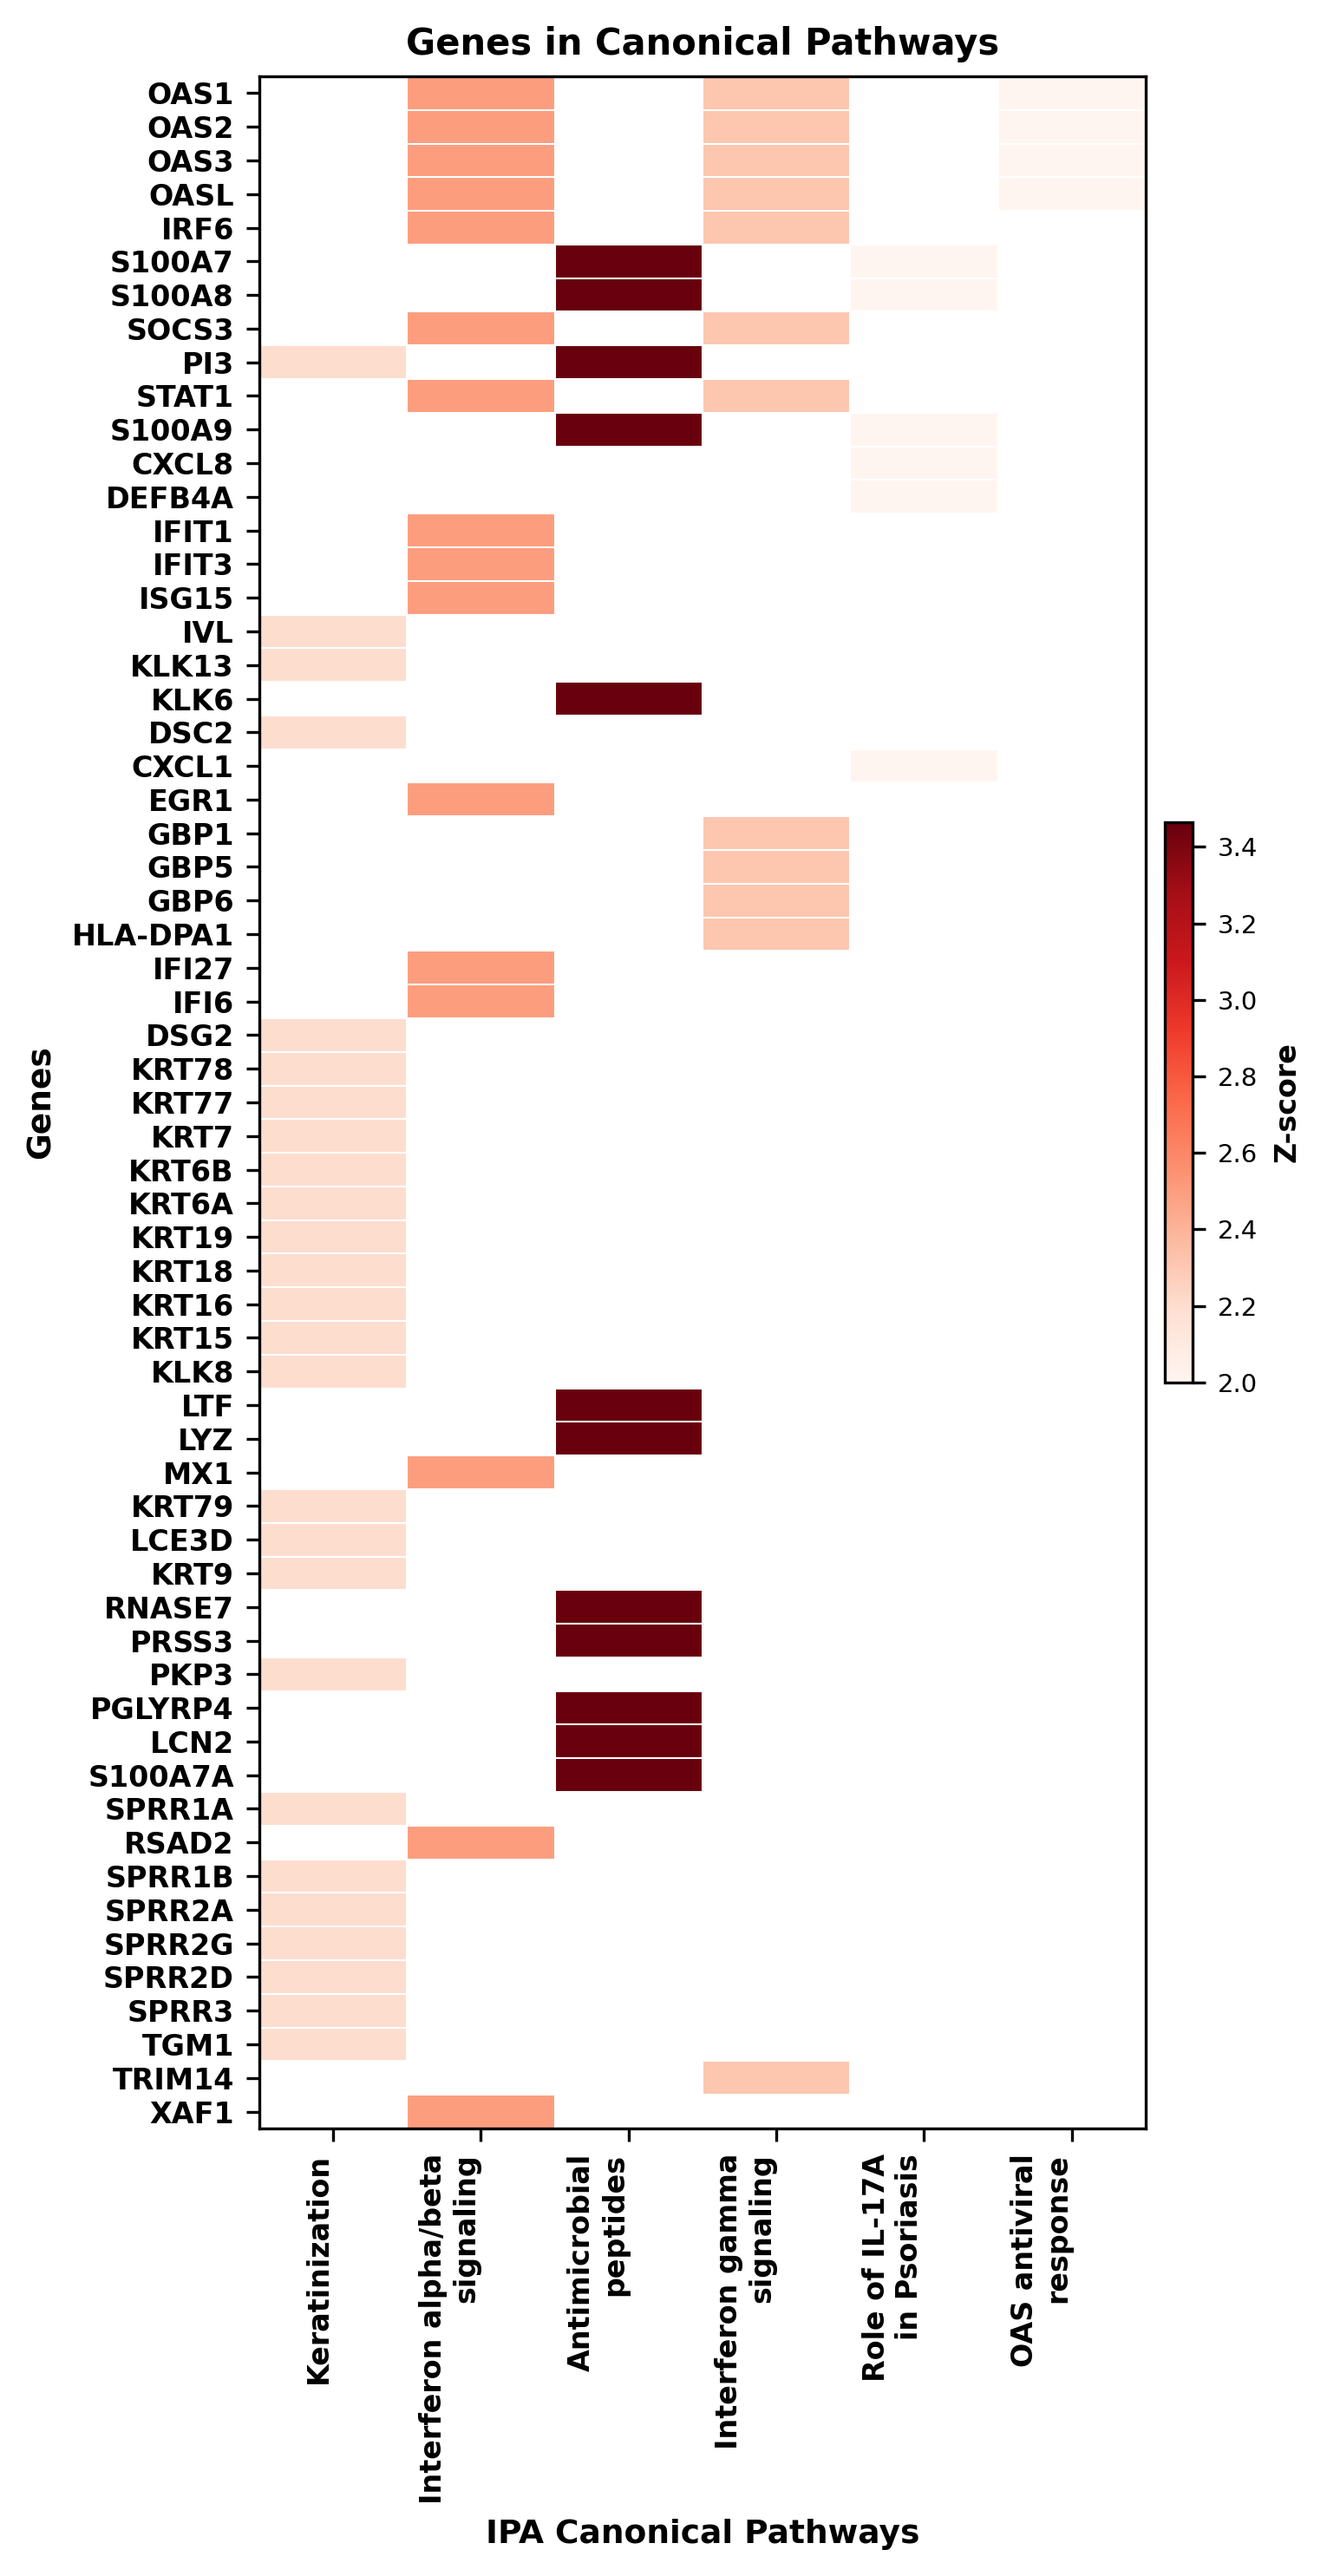

In [30]:
# -*- coding: utf-8 -*-
# Compact Heatmap: Genes × IPA Canonical Pathways
# - Pathway names on 2 lines, right-aligned
# - Reduced height and width
# - Bold ticks/labels, 300 DPI

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Input data (Canonical Pathways with z-scores)
# -----------------------------
rows = [
    {"Pathway": "Antimicrobial\npeptides", "zscore": 3.464,
     "Molecules": "KLK6,LCN2,LTF,LYZ,PGLYRP4,PI3,PRSS3,RNASE7,S100A7,S100A7A,S100A8,S100A9"},
    {"Pathway": "Interferon alpha/beta\nsignaling", "zscore": 2.5,
     "Molecules": "EGR1,IFI27,IFI6,IFIT1,IFIT3,IRF6,ISG15,MX1,OAS1,OAS2,OAS3,OASL,RSAD2,SOCS3,STAT1,XAF1"},
    {"Pathway": "Interferon gamma\nsignaling", "zscore": 2.309,
     "Molecules": "GBP1,GBP5,GBP6,HLA-DPA1,IRF6,OAS1,OAS2,OAS3,OASL,SOCS3,STAT1,TRIM14"},
    {"Pathway": "Keratinization", "zscore": 2.2,
     "Molecules": "DSC2,DSG2,IVL,KLK13,KLK8,KRT15,KRT16,KRT18,KRT19,KRT6A,KRT6B,KRT7,KRT77,KRT78,KRT79,KRT9,"
                  "LCE3D,PI3,PKP3,SPRR1A,SPRR1B,SPRR2A,SPRR2D,SPRR2G,SPRR3,TGM1"},
    {"Pathway": "OAS antiviral\nresponse", "zscore": 2.0,
     "Molecules": "OAS1,OAS2,OAS3,OASL"},
    {"Pathway": "Role of IL-17A\nin Psoriasis", "zscore": 2.0,
     "Molecules": "CXCL1,CXCL8,DEFB4A,S100A7,S100A8,S100A9"}
]
df = pd.DataFrame(rows)

# -----------------------------
# 2) Expand gene lists
# -----------------------------
df_long = (
    df.assign(Gene=df["Molecules"].str.split(","))
      .explode("Gene")
      .drop(columns=["Molecules"])
)
df_long["Gene"] = df_long["Gene"].str.strip()

# -----------------------------
# 3) Build z-score matrix
# -----------------------------
mat = df_long.pivot_table(index="Gene", columns="Pathway", values="zscore", aggfunc="max")

# -----------------------------
# 4) Order for readability
# -----------------------------
presence = (~mat.isna()).astype(int)
pathway_order = presence.sum(axis=0).sort_values(ascending=False).index
gene_order = presence.sum(axis=1).sort_values(ascending=False).index
mat = mat.loc[gene_order, pathway_order]

# -----------------------------
# 5) Plot heatmap
# -----------------------------
n_rows, n_cols = mat.shape
fig, ax = plt.subplots(figsize=(5.2, 10), dpi=300)  # reduced width & height

data = mat.to_numpy(dtype=float)
mask = np.isnan(data)
masked_data = np.ma.masked_array(data, mask=mask)

im = ax.imshow(masked_data, aspect="auto", interpolation="nearest", cmap="Reds")
im.set_clim(np.nanmin(data), np.nanmax(data))

# Background
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# Axis ticks and labels
ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))
ax.set_xticklabels(mat.columns, rotation=90, fontsize=8, fontweight="bold", ha='right')  # right aligned
ax.set_yticklabels(mat.index, fontsize=8, fontweight="bold")

ax.set_xlabel("IPA Canonical Pathways", fontweight="bold", fontsize=9)
ax.set_ylabel("Genes", fontweight="bold", fontsize=9)
ax.set_title("Genes in Canonical Pathways", fontweight="bold", fontsize=10)

# Grid
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Z-score", fontweight="bold", fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()

# -----------------------------
# 6) Save 300 DPI output
# -----------------------------
out_png = "IPA_CanonicalPathways_Compact_RightAlign_300dpi.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"✅ Saved: {out_png}")
